# Demand Forecasting Modeling

This notebook develops forecasting models for the top-selling product families.

The workflow includes:

- Time series preparation
- Feature engineering
- Baseline forecasting models
- LightGBM forecasting
- Prophet comparison
- Model evaluation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import lightgbm as lgb

from prophet import Prophet

import joblib

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/train.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
TOP_FAMILIES = [
    "GROCERY I",
    "BEVERAGES",
    "PRODUCE",
    "CLEANING",
    "DAIRY"
]

In [4]:
family_daily = (
    df
    .groupby(["date", "family"])["sales"]
    .sum()
    .reset_index()
)

family_daily = family_daily[
    family_daily["family"].isin(TOP_FAMILIES)
]

family_daily.head()

,date,family,sales
3,2013-01-01,BEVERAGES,810.0
7,2013-01-01,CLEANING,186.0
8,2013-01-01,DAIRY,143.0
12,2013-01-01,GROCERY I,700.0
30,2013-01-01,PRODUCE,0.0


In [5]:
family_daily.info()

<class 'pandas.DataFrame'>
Index: 8420 entries, 3 to 55569
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8420 non-null   datetime64[us]
 1   family  8420 non-null   str           
 2   sales   8420 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 263.1 KB


In [6]:
family_daily["family"].value_counts()

family
BEVERAGES    1684
CLEANING     1684
DAIRY        1684
GROCERY I    1684
PRODUCE      1684
Name: count, dtype: int64

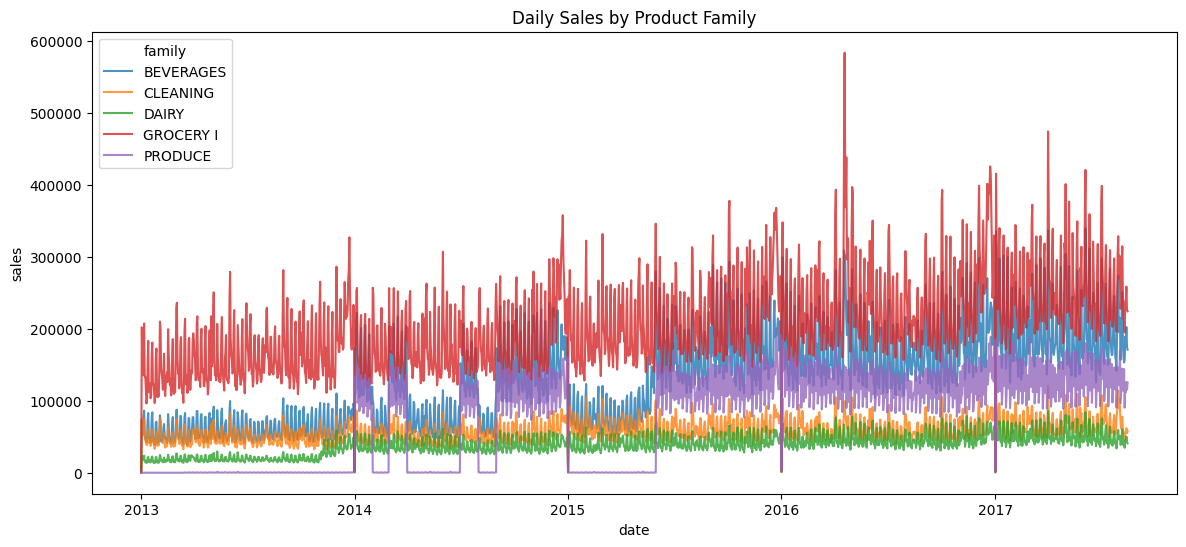

In [7]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=family_daily,
    x="date",
    y="sales",
    hue="family",
    alpha=0.8
)

plt.title("Daily Sales by Product Family")
plt.show()

In [8]:
family_daily = family_daily.sort_values(
    ["family", "date"]
).reset_index(drop=True)

family_daily.head()

,date,family,sales
0,2013-01-01,BEVERAGES,810.0
1,2013-01-02,BEVERAGES,72092.0
2,2013-01-03,BEVERAGES,52105.0
3,2013-01-04,BEVERAGES,54167.0
4,2013-01-05,BEVERAGES,77818.0


In [9]:
family_daily["year"] = family_daily["date"].dt.year
family_daily["month"] = family_daily["date"].dt.month
family_daily["day"] = family_daily["date"].dt.day
family_daily["day_of_week"] = family_daily["date"].dt.dayofweek
family_daily["quarter"] = family_daily["date"].dt.quarter
family_daily["week_of_year"] = family_daily["date"].dt.isocalendar().week.astype(int)
family_daily["is_weekend"] = (
    family_daily["day_of_week"] >= 5
).astype(int)

In [10]:
family_daily["month_sin"] = np.sin(
    2*np.pi*family_daily["month"]/12
)

family_daily["month_cos"] = np.cos(
    2*np.pi*family_daily["month"]/12
)

In [11]:
promotion_daily = (
    df.groupby(["date", "family"])["onpromotion"]
      .sum()
      .reset_index()
)

family_daily = family_daily.merge(
    promotion_daily,
    on=["date", "family"],
    how="left"
)

family_daily["has_promotion"] = (
    family_daily["onpromotion"] > 0
).astype(int)

In [12]:
family_daily["lag_1"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(1)
)

In [13]:
family_daily["lag_7"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(7)
)

In [14]:
family_daily["lag_30"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(30)
)

In [15]:
family_daily["rolling_mean_7"] = (
    family_daily
    .groupby("family")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [16]:
family_daily["rolling_mean_30"] = (
    family_daily
    .groupby("family")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

In [17]:
family_daily.head(15)

,date,family,sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,onpromotion,has_promotion,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-01,BEVERAGES,810.0,2013,1,1,1,1,1,0,0.5,0.866025,0,0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,BEVERAGES,72092.0,2013,1,2,2,1,1,0,0.5,0.866025,0,0,810.0,NaN,NaN,NaN,NaN
2,2013-01-03,BEVERAGES,52105.0,2013,1,3,3,1,1,0,0.5,0.866025,0,0,72092.0,NaN,NaN,NaN,NaN
3,2013-01-04,BEVERAGES,54167.0,2013,1,4,4,1,1,0,0.5,0.866025,0,0,52105.0,NaN,NaN,NaN,NaN
4,2013-01-05,BEVERAGES,77818.0,2013,1,5,5,1,1,1,0.5,0.866025,0,0,54167.0,NaN,NaN,NaN,NaN
5,2013-01-06,BEVERAGES,86184.0,2013,1,6,6,1,1,1,0.5,0.866025,0,0,77818.0,NaN,NaN,NaN,NaN
6,2013-01-07,BEVERAGES,51619.0,2013,1,7,0,1,2,0,0.5,0.866025,0,0,86184.0,NaN,NaN,NaN,NaN
7,2013-01-08,BEVERAGES,46941.0,2013,1,8,1,1,2,0,0.5,0.866025,0,0,51619.0,810.0,NaN,56399.285714,NaN
8,2013-01-09,BEVERAGES,47910.0,2013,1,9,2,1,2,0,0.5,0.866025,0,0,46941.0,72092.0,NaN,62989.428571,NaN
9,2013-01-10,BEVERAGES,42390.0,2013,1,10,3,1,2,0,0.5,0.866025,0,0,47910.0,52105.0,NaN,59534.857143,NaN


In [18]:
family_daily[
    [
        "lag_1",
        "lag_7",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_30"
    ]
].isnull().sum()

lag_1                5
lag_7               35
lag_30             150
rolling_mean_7      35
rolling_mean_30    150
dtype: int64

In [19]:
family_daily = family_daily.dropna().reset_index(drop=True)

In [20]:
family_daily.isnull().sum()

date               0
family             0
sales              0
year               0
month              0
day                0
day_of_week        0
quarter            0
week_of_year       0
is_weekend         0
month_sin          0
month_cos          0
onpromotion        0
has_promotion      0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64

### Feature Engineering Summary

Temporal features were created independently for each product family.

The following features were generated:

- Calendar variables (year, month, quarter, weekday, week of year)
- Cyclical month encoding (sin/cos)
- Promotion indicator
- Lag features (1, 7 and 30 days)
- Rolling averages (7 and 30 days)

The lag and rolling features naturally introduce missing values at the beginning of each time series because historical observations are unavailable. These rows are removed before model training to avoid incomplete feature vectors.

In [21]:
TRAIN_END = "2016-12-31"
VAL_END = "2017-05-31"

In [22]:
train = family_daily[
    family_daily["date"] <= TRAIN_END
].copy()

val = family_daily[
    (family_daily["date"] > TRAIN_END) &
    (family_daily["date"] <= VAL_END)
].copy()

test = family_daily[
    family_daily["date"] > VAL_END
].copy()

In [23]:
print("TRAIN")
print(train["date"].min(), "->", train["date"].max())
print(len(train))

print()

print("VALIDATION")
print(val["date"].min(), "->", val["date"].max())
print(len(val))

print()

print("TEST")
print(test["date"].min(), "->", test["date"].max())
print(len(test))

TRAIN
2013-01-31 00:00:00 -> 2016-12-31 00:00:00
7135

VALIDATION
2017-01-01 00:00:00 -> 2017-05-31 00:00:00
755

TEST
2017-06-01 00:00:00 -> 2017-08-15 00:00:00
380


In [24]:
train["family"].value_counts()

family
BEVERAGES    1427
CLEANING     1427
DAIRY        1427
GROCERY I    1427
PRODUCE      1427
Name: count, dtype: int64

In [25]:
val["family"].value_counts()

family
BEVERAGES    151
CLEANING     151
DAIRY        151
GROCERY I    151
PRODUCE      151
Name: count, dtype: int64

In [26]:
test["family"].value_counts()

family
BEVERAGES    76
CLEANING     76
DAIRY        76
GROCERY I    76
PRODUCE      76
Name: count, dtype: int64

### Temporal Data Split

The dataset was divided chronologically to preserve the temporal structure.

- Training: January 2013 – December 2016
- Validation: January 2017 – May 2017
- Test: June 2017 – August 2017

A random split was intentionally avoided because it would introduce future information into the training process (data leakage), producing overly optimistic performance estimates.

In [27]:
FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend",
    "month_sin",
    "month_cos",
    "has_promotion"
]

TARGET = "sales"

In [28]:
X_train = train[FEATURES]
y_train = train[TARGET]

In [29]:
X_val = val[FEATURES]
y_val = val[TARGET]

In [30]:
X_test = test[FEATURES]
y_test = test[TARGET]

In [31]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7135, 15)
Validation: (755, 15)
Test: (380, 15)


In [32]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0
0


In [33]:
X_train.head()

,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,has_promotion
0,44583.0,38394.0,810.0,50410.428571,54252.500000,2013,1,31,3,1,5,0,0.500000,0.866025,0
1,43078.0,46689.0,72092.0,51079.571429,55661.433333,2013,2,1,4,1,5,0,0.866025,0.500000,0
2,56866.0,69586.0,52105.0,52533.428571,55153.900000,2013,2,2,5,1,5,1,0.866025,0.500000,0
3,79804.0,70851.0,54167.0,53993.142857,56077.200000,2013,2,3,6,1,5,1,0.866025,0.500000,0
4,72329.0,42178.0,77818.0,54204.285714,56682.600000,2013,2,4,0,1,6,0,0.866025,0.500000,0


In [34]:
naive_pred = test["lag_1"]

In [35]:
seasonal_naive = test["lag_7"]

In [36]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"{name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")
    print("-"*35)

    return mae, rmse, r2

In [37]:
naive_results = evaluate_model(
    "Naive Forecast",
    y_test,
    naive_pred
)

Naive Forecast
MAE : 24660.90
RMSE: 34977.36
R²  : 0.8238
-----------------------------------


In [38]:
seasonal_results = evaluate_model(
    "Seasonal Naive",
    y_test,
    seasonal_naive
)

Seasonal Naive
MAE : 16692.20
RMSE: 25335.03
R²  : 0.9076
-----------------------------------


### Baseline Results

The Seasonal Naive model clearly outperformed the simple Naive approach across all evaluation metrics.

This result confirms one of the main findings from the exploratory data analysis: retail sales exhibit a strong weekly seasonal pattern. Consequently, using the sales from the same weekday of the previous week provides a much stronger baseline than relying only on the previous day's sales.

These baseline models establish a solid benchmark that advanced machine learning models must surpass to justify their additional complexity.

In [39]:
baseline_results = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MAE": [naive_results[0], seasonal_results[0]],
    "RMSE": [naive_results[1], seasonal_results[1]],
    "R2": [naive_results[2], seasonal_results[2]]
})

baseline_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Seasonal Naive,16692.201646,25335.033159,0.907562
0,Naive,24660.898287,34977.358757,0.823811


In [40]:
train_data = lgb.Dataset(
    X_train,
    label=y_train
)

val_data = lgb.Dataset(
    X_val,
    label=y_val,
    reference=train_data
)

In [41]:
params = {
    "objective": "regression",
    "metric": "rmse",

    "learning_rate": 0.05,

    "num_leaves": 64,

    "min_data_in_leaf": 20,

    "feature_fraction": 0.8,

    "bagging_fraction": 0.8,

    "bagging_freq": 5,

    "verbosity": -1,

    "seed": 42
}

In [42]:
model_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=["Train", "Validation"],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	Train's rmse: 14092.9	Validation's rmse: 30915.7
[100]	Train's rmse: 10505.4	Validation's rmse: 28669.8
[150]	Train's rmse: 8804.99	Validation's rmse: 27523.2
[200]	Train's rmse: 7809.89	Validation's rmse: 26928.9
[250]	Train's rmse: 7031.19	Validation's rmse: 26586.8
[300]	Train's rmse: 6447.83	Validation's rmse: 26543.1
[350]	Train's rmse: 5940.33	Validation's rmse: 26396.6
[400]	Train's rmse: 5525.43	Validation's rmse: 26259.3
[450]	Train's rmse: 5152.53	Validation's rmse: 26262.4
Early stopping, best iteration is:
[429]	Train's rmse: 5295.43	Validation's rmse: 26156.5


In [43]:
lgb.early_stopping(50)

In [44]:
pred_lgb = model_lgb.predict(
    X_test
)

In [45]:
lgb_results = evaluate_model(
    "LightGBM",
    y_test,
    pred_lgb
)

LightGBM
MAE : 10041.82
RMSE: 15175.76
R²  : 0.9668
-----------------------------------


### LightGBM Performance

LightGBM substantially outperformed both baseline forecasting models across every evaluation metric.

Compared to the Seasonal Naive benchmark, the model reduced RMSE from **25,335** to **15,176** (approximately a **40% reduction**) while increasing the coefficient of determination (R²) from **0.91** to **0.97**.

These results demonstrate that combining lag features, rolling statistics, calendar features and promotion information enables the model to capture complex demand patterns that simple historical baselines cannot represent.